## Import libraries

In [1]:
import os
import pandas as pd
import glob
import pickle
import time
import seaborn as sns

from dask.diagnostics import ProgressBar

from arboreto.algo import grnboost2, genie3
from arboreto.utils import load_tf_names

from pyscenic.rnkdb import FeatherRankingDatabase as RankingDatabase
from pyscenic.utils import modules_from_adjacencies, load_motifs
from pyscenic.prune import prune2df, df2regulons
from pyscenic.aucell import aucell
from pyscenic.binarization import binarize

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Change working directory to pySCENIC src directory

In [2]:
base_dir = os.path.expanduser('~/Desktop/miner3/miner')
resources_folder = os.path.join(base_dir, 'data')
results_folder   = os.path.join(base_dir, 'TCGA_KICH_pyscenic_results')
expression_path  = os.path.join(resources_folder, 'expression', 'TCGA_KICH', 'TCGA_KICH_Zscore.csv')
tf_path          = os.path.join(resources_folder, 'hs_hgnc_curated_tfs.txt')

## Read expression matrix; Genes should be columns

In [3]:
ex_matrix = pd.read_csv(expression_path,index_col = 0)

## Load TF names

In [4]:
tf_path = resources_folder + '/hs_hgnc_tfs.txt'

## Subset expression matrix to facilitate runtime

In [5]:
import os
path = os.path.expanduser('~/Desktop/miner3/miner/data/expression/TCGA_KICH/TCGA_KICH_Zscore.csv')
print(os.path.exists(path))   
print(os.path.getsize(path))  

True
52480244


import mygene

expression_path = os.path.expanduser('~/Desktop/miner3/miner/data/expression/NAFLD/NAFLD_Zscore.csv')
ex_matrix = pd.read_csv(expression_path, index_col=0)
ex_matrix = ex_matrix.T

# Convert Ensembl IDs to gene symbols
mg = mygene.MyGeneInfo()
ensembl_ids = list(ex_matrix.columns)

result = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=True)

# Build mapping dict
id_to_symbol = result['symbol'].dropna().to_dict()

# Rename columns
ex_matrix.columns = [id_to_symbol.get(col, col) for col in ex_matrix.columns]

# Drop unmapped columns (still look like ENSG...)
ex_matrix = ex_matrix.loc[:, ~ex_matrix.columns.str.startswith('ENSG')]

# Remove duplicate gene symbols if any
ex_matrix = ex_matrix.loc[:, ~ex_matrix.columns.duplicated()]

# Load TFs and verify
tf_path = os.path.expanduser('~/Desktop/miner3/miner/data/hs_hgnc_tfs.txt')
tf_names = load_tf_names(tf_path)

print("Shape after mapping:", ex_matrix.shape)
print("Common genes with TF list:", len(set(ex_matrix.columns) & set(tf_names)))

In [6]:
expression_path = os.path.expanduser(
    '~/Desktop/miner3/miner/data/expression/TCGA_KICH/TCGA_KICH_Zscore.csv'
)
ex_matrix = pd.read_csv(expression_path, index_col=0)
ex_matrix = ex_matrix.T  # rows = samples, cols = genes

# Load TFs and verify overlap
tf_path = os.path.expanduser('~/Desktop/miner3/miner/data/hs_hgnc_tfs.txt')
tf_names = load_tf_names(tf_path)

print("Shape after loading:", ex_matrix.shape)
print("First 5 column names:", list(ex_matrix.columns[:5]))
print("Common genes with TF list:", len(set(ex_matrix.columns) & set(tf_names)))

Shape after loading: (66, 39667)
First 5 column names: ['5S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF']
Common genes with TF list: 1818


In [7]:
# record times
# Num genes   minutes   Num TFs
# 182         0.298     100
# 481         0.805     100
# 880         1.788     100
# 955         2.651     200
# 2282        10.769    400       

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

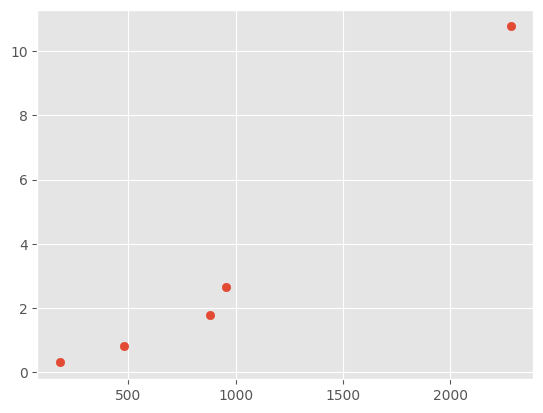

In [9]:
plt.scatter([182,481,880,955,2282],[0.298,0.805,1.788,2.651,10.769])

## Apply GRNBoost2 to generate adjacency matrix

In [10]:
from arboreto.utils import load_tf_names

# Use the official TF list you downloaded into miner/data
tf_path = os.path.expanduser('~/Desktop/miner3/miner/data/hs_hgnc_tfs.txt')

# Load transcription factor names
tf_names = load_tf_names(tf_path)

print("Number of TFs loaded:", len(tf_names))
print(tf_names[:10])

Number of TFs loaded: 1839
['HOXA9', 'ZNF8', 'ZNF853', 'NR1H2', 'NR1H3', 'NR1H4', 'NR1I2', 'NR1I3', 'NR2F1', 'NR2F6']


In [11]:
import dask
print("dask:", dask.__version__)

import pkg_resources
print("arboreto:", pkg_resources.get_distribution("arboreto").version)

dask: 2021.11.2
arboreto: 0.1.6


import mygene
import time

mg = mygene.MyGeneInfo()
ensembl_ids = [g.split('.')[0] for g in ex_matrix.columns]

# Query in chunks of 500 to avoid server errors
id_to_symbol = {}
chunk_size = 500
failed_chunks = 0

for i in range(0, len(ensembl_ids), chunk_size):
    chunk = ensembl_ids[i:i+chunk_size]
    try:
        result = mg.querymany(chunk, scopes='ensembl.gene', fields='symbol', 
                               species='human', returnall=True, verbose=False)
        for r in result['out']:
            if 'symbol' in r:
                id_to_symbol[r['query']] = r['symbol']
        time.sleep(0.5)  # be polite to the server
    except Exception as e:
        print(f"Chunk {i//chunk_size + 1} failed: {e}")
        failed_chunks += 1
        time.sleep(2)  # wait longer before next chunk
        continue

print(f"Mapped {len(id_to_symbol)} out of {len(ensembl_ids)} genes")
print(f"Failed chunks: {failed_chunks}")

# Find unmapped IDs
mapped_ids = set(id_to_symbol.keys())
unmapped_ids = [eid for eid in ensembl_ids if eid not in mapped_ids]
print(f"Unmapped IDs to retry: {len(unmapped_ids)}")

# Retry with smaller chunks and longer delay
chunk_size = 100
still_failed = []

for i in range(0, len(unmapped_ids), chunk_size):
    chunk = unmapped_ids[i:i+chunk_size]
    try:
        result = mg.querymany(chunk, scopes='ensembl.gene', fields='symbol',
                               species='human', returnall=True, verbose=False)
        for r in result['out']:
            if 'symbol' in r:
                id_to_symbol[r['query']] = r['symbol']
        time.sleep(1)
    except Exception as e:
        still_failed.extend(chunk)
        time.sleep(3)
        continue

print(f"Total mapped now: {len(id_to_symbol)} out of {len(ensembl_ids)}")
print(f"Still unmapped: {len(ensembl_ids) - len(id_to_symbol)}")

# Apply the mapping to ex_matrix columns

new_cols = []

for g in ex_matrix.columns:
    eid = g.split('.')[0]

    if eid in id_to_symbol:
        new_cols.append(id_to_symbol[eid].upper())
    else:
        new_cols.append(g)

ex_matrix.columns = new_cols

print(ex_matrix.columns[:20])

ex_matrix = ex_matrix.loc[:, ~ex_matrix.columns.duplicated()]

print("Shape after removing duplicates:")
print(ex_matrix.shape)

print("Remaining duplicates:",
      ex_matrix.columns.duplicated().sum())

In [12]:
# Select top 5000 most variable genes only
gene_variances = ex_matrix.var(axis=0)
top5000_genes = gene_variances.nlargest(5000).index.tolist()
ex_matrix_small = ex_matrix[top5000_genes]

# Filter TFs to only those present in the subset
tf_names_filtered = [tf for tf in tf_names if tf in top5000_genes]
print(f"Genes: {len(top5000_genes)}, TFs: {len(tf_names_filtered)}")

# Run GRNBoost2 on subset
t1 = time.time()
adjacency = grnboost2(
    expression_data=ex_matrix_small,
    gene_names=list(ex_matrix_small.columns),
    tf_names=tf_names_filtered,
    verbose=True
)
t2 = time.time()
print((t2-t1)/60.0)
adjacency.head()

Genes: 5000, TFs: 341
preparing dask client
parsing input
creating dask graph
5 partitions
computing dask graph
shutting down client and local cluster
finished
1.3210206151008606


,TF,target,importance
9,KDM5D,USP9Y,134.190926
9,KDM5D,RPS4Y1,126.884617
55,ZFY,GYG2P1,122.438259
55,ZFY,USP9Y,101.178445
55,ZFY,RPS4Y1,101.097301


In [13]:
print(f"Total genes in matrix: {ex_matrix.shape[1]}")
print(f"Genes: {len(top5000_genes)}, TFs: {len(tf_names_filtered)}")

Total genes in matrix: 39667
Genes: 5000, TFs: 341


## Write adjacency matrix to file

In [14]:
results_folder = os.path.expanduser('~/Desktop/miner3/miner/TCGA_KICH_pyscenic_results')
os.makedirs(results_folder, exist_ok=True)

In [15]:
adjacency.to_csv(os.path.join(results_folder,'adjacency_tcga_kich.tsv'), sep='\t', header=False, index=False)

## Infer modules from adjacencies matrix

In [16]:
modules = list(modules_from_adjacencies(adjacency, ex_matrix))


2026-07-01 13:12:16,749 - pyscenic.utils - INFO - Calculating Pearson correlations.

2026-07-01 13:12:16,876 - pyscenic.utils - WARNING - Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current default is now to use all cells to match the behavior of the R verision of SCENIC. The original settings can be retained by setting 'rho_mask_dropouts=True' in the modules_from_adjacencies function, or '--mask_dropouts' from the CLI.
	Dropout masking is currently set to [False].

2026-07-01 13:12:19,744 - pyscenic.utils - INFO - Creating modules.


In [17]:
len(modules)

2024

In [18]:
import pickle
checkpoint = {
    'ex_matrix': ex_matrix,
    'ex_matrix_small': ex_matrix_small,
    'tf_names': tf_names,
    'tf_names_filtered': tf_names_filtered,
    'adjacency': adjacency,
    'modules': modules
}
with open(os.path.expanduser('~/Desktop/miner3/miner/TCGA_KICH_pyscenic_results/checkpoint.pkl'), 'wb') as f:
    pickle.dump(checkpoint, f)
print("Checkpoint saved!")

Checkpoint saved!


In [19]:
# Run this instead of rerunning heavy cells
with open(os.path.expanduser('~/Desktop/miner3/miner/TCGA_KICH_pyscenic_results/checkpoint.pkl'), 'rb') as f:
    cp = pickle.load(f)
ex_matrix = cp['ex_matrix']
ex_matrix_small = cp['ex_matrix_small']
tf_names = cp['tf_names']
tf_names_filtered = cp['tf_names_filtered']
adjacency = cp['adjacency']
modules = cp['modules']
print("Restored!")

Restored!


## Load TF motif database

In [20]:
# Filenames for saving
REGULONS_FNAME = os.path.join(results_folder, "regulons.p")
MOTIFS_FNAME = os.path.join(results_folder, "motifs.csv")

# Load motif database
MOTIF_ANNOTATIONS_FNAME = os.path.join(resources_folder, "motifs-v9-nr.hgnc-m0.001-o0.0.tbl")
DATABASES_GLOB = os.path.join(resources_folder, "hg38__refseq-r80__10kb_up_and_down_tss.mc9nr.genes_vs_motifs.rankings.feather")

# Rank databases
db_fnames = glob.glob(DATABASES_GLOB)
def name(fname):
    return os.path.splitext(os.path.basename(fname))[0]
dbs = [RankingDatabase(fname=fname, name=name(fname)) for fname in db_fnames]
dbs

[FeatherRankingDatabase(name="hg38__refseq-r80__10kb_up_and_down_tss.mc9nr.genes_vs_motifs.rankings")]

## Mechanistic inference of regulons

# Calculate a list of enriched motifs and the corresponding target genes for all modules.
with ProgressBar():
    df = prune2df(dbs, modules, MOTIF_ANNOTATIONS_FNAME)

# Create regulons from this table of enriched motifs.
regulons = df2regulons(df)

# Save the enriched motifs and the discovered regulons to disk.
df.to_csv(MOTIFS_FNAME)
with open(REGULONS_FNAME, "wb") as f:
    pickle.dump(regulons, f)

In [21]:
# Skip prune2df - restore regulons from checkpoint
with open(os.path.expanduser('~/Desktop/miner3/miner/TCGA_KICH_pyscenic_results/checkpoint.pkl'), 'rb') as f:
    cp = pickle.load(f)
ex_matrix = cp['ex_matrix']
ex_matrix_small = cp['ex_matrix_small']
tf_names = cp['tf_names']
tf_names_filtered = cp['tf_names_filtered']
adjacency = cp['adjacency']
modules = cp['modules']

# Create regulons from modules directly
from pyscenic.genesig import Regulon
regulons = []
for module in modules:
    regulon = Regulon(
        name=module.transcription_factor + '(+)',
        gene2weight={gene: 1.0 for gene in module.genes},
        transcription_factor=module.transcription_factor,
        gene2occurrence={}
    )
    regulons.append(regulon)

print(f"Restored! Regulons: {len(regulons)}")

Restored! Regulons: 2024


## Run AUCell

Unmapped rows: 0
['TCGA-KN-8422', 'TCGA-KO-8414', 'TCGA-KN-8424', 'TCGA-KL-8332', 'TCGA-KN-8421']


/opt/anaconda3/envs/pyscenic_env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Saved!


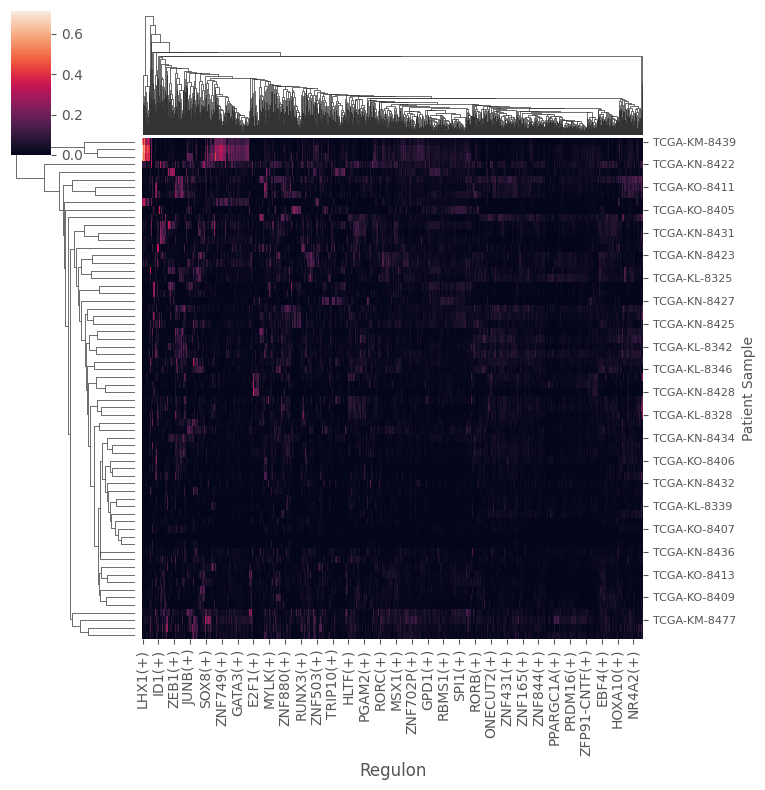

In [22]:
# Step 0: Load metadata (add this since kernel was restarted)
import pandas as pd
meta = pd.read_csv("~/Desktop/miner3/miner/TCGA_data/raw/tcga_kich_metadata.csv")

# Step 1: Run AUCell
auc_mtx = aucell(ex_matrix, regulons, num_workers=4)

# Step 2: Build mapping from metadata
uuid_to_barcode = dict(zip(meta['external_id'], meta['tcga.tcga_barcode']))

# Step 3: Rename index IMMEDIATELY after AUCell
auc_mtx.index = auc_mtx.index.map(uuid_to_barcode)

# Step 3.5: Shorten barcodes to TCGA-XX-XXXX format
auc_mtx.index = auc_mtx.index.str.extract(r'(TCGA-\w{2}-\w{4})')[0]

# Step 4: Verify
print("Unmapped rows:", auc_mtx.index.isna().sum())
print(auc_mtx.index[:5].tolist())

# Step 5: Plot
g = sns.clustermap(auc_mtx, figsize=(8, 8))  # original size restored
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=8  # tiny font to prevent congestion at original size
)
g.ax_heatmap.set_ylabel("Patient Sample", fontsize=10)

g.savefig(os.path.join(results_folder, 'auc_heatmap.png'),
          format='png', dpi=150, bbox_inches='tight')
print("Saved!")

In [23]:
auc_mtx.head()

Regulon,ADARB1(+),AFF4(+),ANXA1(+),AR(+),ARID5A(+),ARID5B(+),ARNT2(+),ASCL1(+),ATF3(+),ATOH8(+),...,ZNF74(+),ZNF749(+),ZNF826P(+),ZNF844(+),ZNF853(+),ZNF880(+),ZNF98(+),ZNF99(+),ZSCAN18(+),ZSCAN31(+)
0,,,,,,,,,,,,,,,,,,,,,
TCGA-KN-8422,0.029306,0.015601,0.049701,0.024430,0.032571,0.021237,0.086799,0.049965,0.055187,0.049526,...,0.045098,0.038584,0.031861,0.063151,0.055382,0.042770,0.030247,0.062170,0.027501,0.082384
TCGA-KO-8414,0.002914,0.001659,0.010755,0.000292,0.006964,0.000342,0.007920,0.010973,0.002254,0.001920,...,0.018089,0.003907,0.004222,0.005971,0.005155,0.001353,0.004776,0.011897,0.004455,0.009321
TCGA-KN-8424,0.015525,0.032805,0.049312,0.062154,0.029922,0.038882,0.014867,0.073981,0.033550,0.011870,...,0.029406,0.016212,0.057793,0.023576,0.026691,0.058454,0.021179,0.053122,0.042184,0.019191
TCGA-KL-8332,0.027015,0.028825,0.019576,0.060404,0.022796,0.042709,0.021774,0.015402,0.054831,0.022011,...,0.024999,0.010649,0.051095,0.019014,0.018851,0.016506,0.007947,0.018850,0.019375,0.049962
TCGA-KN-8421,0.029667,0.010548,0.011740,0.012291,0.009976,0.015268,0.015276,0.024911,0.010521,0.035163,...,0.030899,0.013232,0.010911,0.017027,0.027963,0.014878,0.013684,0.023557,0.015277,0.021466


In [24]:
auc_mtx.to_csv(os.path.join(results_folder,"auc_matrix.csv"))

## Binarize regulon activity

In [25]:
# Custom binarize implementation (replaces broken pyscenic binarize)
import numpy as np
import pandas as pd

def custom_binarize(auc_mtx):
    thresholds = auc_mtx.mean() + auc_mtx.std()
    binary_mtx = (auc_mtx > thresholds).astype(int)
    return binary_mtx, thresholds

binary_mtx, auc_thresholds = custom_binarize(auc_mtx)
print("Binary matrix shape:", binary_mtx.shape)
binary_mtx.head()

Binary matrix shape: (66, 2024)


Regulon,ADARB1(+),AFF4(+),ANXA1(+),AR(+),ARID5A(+),ARID5B(+),ARNT2(+),ASCL1(+),ATF3(+),ATOH8(+),...,ZNF74(+),ZNF749(+),ZNF826P(+),ZNF844(+),ZNF853(+),ZNF880(+),ZNF98(+),ZNF99(+),ZSCAN18(+),ZSCAN31(+)
0,,,,,,,,,,,,,,,,,,,,,
TCGA-KN-8422,1,0,1,0,0,0,1,1,1,1,...,1,0,0,1,1,1,0,1,0,1
TCGA-KO-8414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-KN-8424,0,1,1,1,0,1,0,1,0,0,...,0,0,1,0,0,1,0,1,0,0
TCGA-KL-8332,0,1,0,1,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
TCGA-KN-8421,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# Check how many 1s exist across the whole matrix
print("Total 1s:", binary_mtx.values.sum())
print("Total cells:", binary_mtx.shape[0])
print("Total regulons:", binary_mtx.shape[1])
print("Fraction active:", binary_mtx.values.mean().round(4))

# Check which regulons have the most active cells
top_regulons = binary_mtx.sum().sort_values(ascending=False).head(10)
print("\nTop 10 most active regulons:")
print(top_regulons)

Total 1s: 16735
Total cells: 66
Total regulons: 2024
Fraction active: 0.1253

Top 10 most active regulons:
Regulon
FOXI1(+)      15
ZNF334(+)     15
NR3C2(+)      15
RPS6KA5(+)    15
ZNF536(+)     15
PRDM1(+)      14
FOXP2(+)      14
FOXD1(+)      14
NCALD(+)      14
NR3C1(+)      14
dtype: int64


In [27]:
binary_mtx.to_csv(os.path.join(results_folder,"binary_regulon_matrix.csv"))

/opt/anaconda3/envs/pyscenic_env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


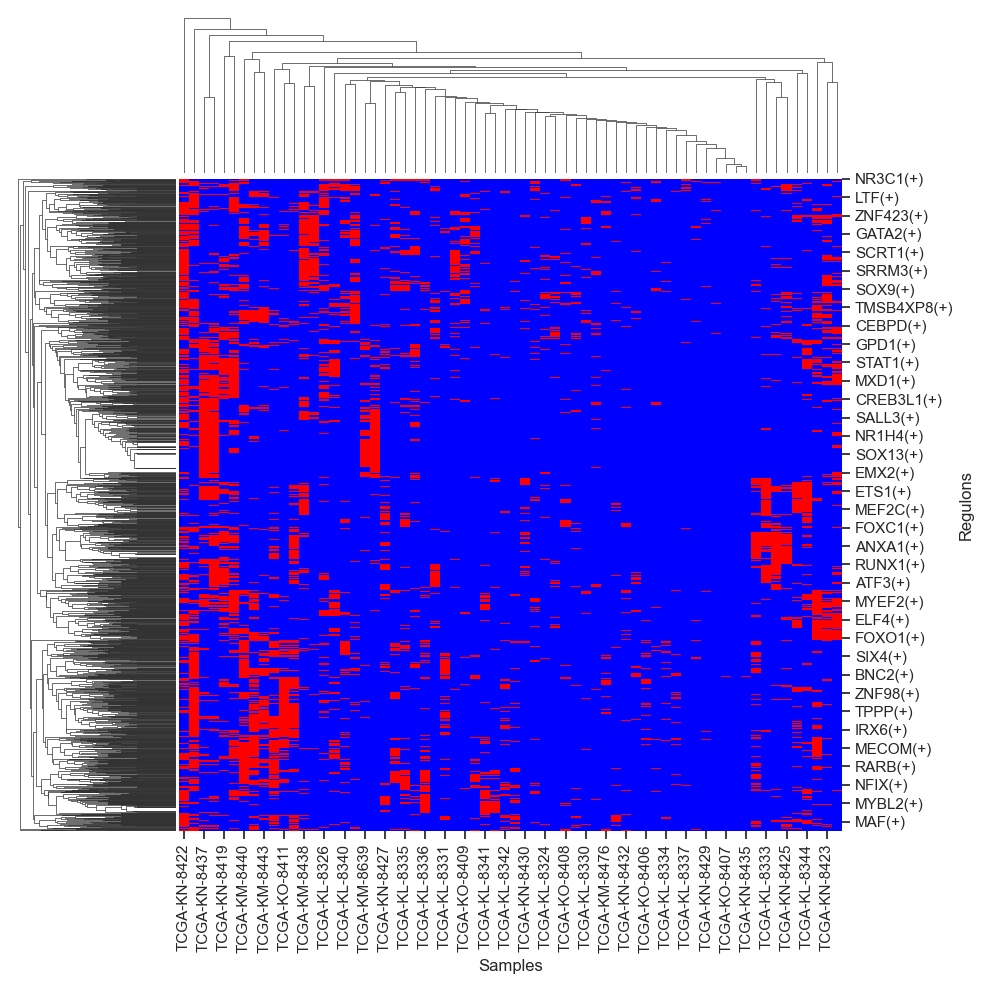

In [28]:
sns.set()
sns.set(font_scale=1.0)
sns.set_style("ticks", {"xtick.minor.size": 1, "ytick.minor.size": 0.1})
g = sns.clustermap(binary_mtx.T, 
               cmap="bwr", figsize=(10,10))

#g.ax_heatmap.set_xticklabels([])
#g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xlabel('Samples')
g.ax_heatmap.set_ylabel('Regulons')

g.cax.set_visible(False)
g.fig.savefig(os.path.join(results_folder, 'scenic_regulon_biclusters.png'), format='png')

## Load MINER regulon matrices

In [29]:
#Set path to MINER results
miner_folder = os.path.expanduser("~/Desktop/miner3/miner/TCGA_KICH_network_results")

In [30]:
#Define MINER regulon file paths
overExpressedMembersMatrix_file = os.path.join(miner_folder,"overExpressedMembers.csv")
underExpressedMembersMatrix_file = os.path.join(miner_folder,"underExpressedMembers.csv")
regulonDf_file = os.path.join(miner_folder,"regulonDf.csv")

In [31]:
# Read MINER regulon files
overExpressedMembersMatrix = pd.read_csv(overExpressedMembersMatrix_file, index_col=0, header=0)
underExpressedMembersMatrix = pd.read_csv(underExpressedMembersMatrix_file, index_col=0, header=0)
regulonDf = pd.read_csv(regulonDf_file, index_col=0, header=0)

# Rename UUID columns to TCGA barcodes ONCE here
uuid_to_barcode = dict(zip(meta['external_id'], meta['tcga.tcga_barcode']))

for df in [overExpressedMembersMatrix, underExpressedMembersMatrix]:
    df.columns = df.columns.map(uuid_to_barcode)
    df.columns = df.columns.str.extract(r'(TCGA-\w{2}-\w{4})')[0].values

In [32]:
#Create difference matrix
diff_mmrf = overExpressedMembersMatrix - underExpressedMembersMatrix
diff_mmrf.head()

,TCGA-KN-8422,TCGA-KO-8414,TCGA-KN-8424,TCGA-KL-8332,TCGA-KN-8421,TCGA-KL-8324,TCGA-KN-8419,TCGA-KL-8338,TCGA-KL-8336,TCGA-KL-8327,...,TCGA-KL-8339,TCGA-KL-8337,TCGA-KL-8341,TCGA-KO-8415,TCGA-KO-8408,TCGA-KL-8343,TCGA-KO-8410,TCGA-KN-8428,TCGA-KN-8433,TCGA-KM-8439
0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,...,1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0
1,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,...,1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0
2,-1.0,-1.0,0.0,0.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,...,1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,0.0,-1.0,1.0
3,0.0,1.0,1.0,1.0,-1.0,-1.0,1.0,0.0,1.0,0.0,...,0.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,0.0,1.0,1.0
4,0.0,-1.0,-1.0,0.0,1.0,1.0,1.0,-1.0,0.0,-1.0,...,-1.0,-1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


## Use clustermap to cluster MINER regulons

/opt/anaconda3/envs/pyscenic_env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


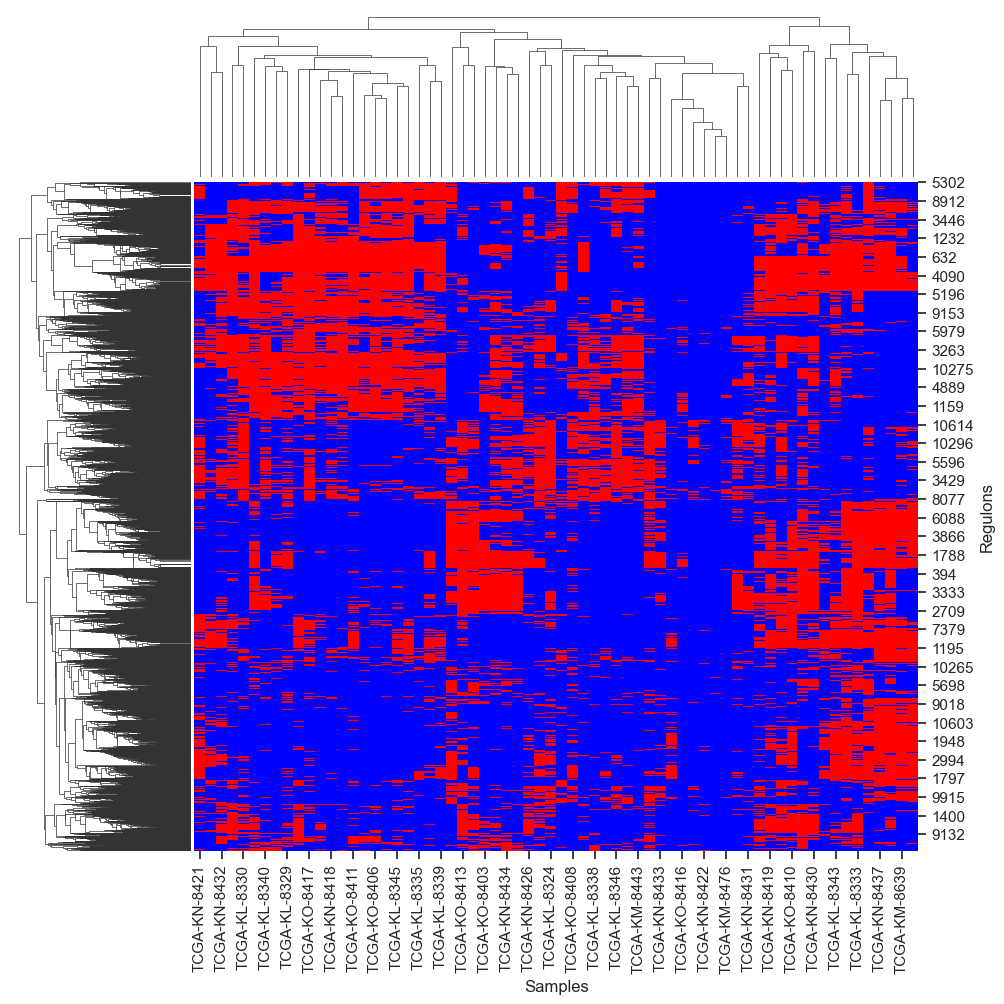

In [33]:
sns.set()
sns.set(font_scale=1.0)
sns.set_style("ticks", {"xtick.minor.size": 1, "ytick.minor.size": 0.1})
g = sns.clustermap(overExpressedMembersMatrix, 
               cmap="bwr", figsize=(10,10))

#g.ax_heatmap.set_xticklabels([])
#g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xlabel('Samples')
g.ax_heatmap.set_ylabel('Regulons')

g.cax.set_visible(False)
g.fig.savefig(os.path.join(results_folder, 'miner_regulon_overexpressed_biclusters.png'), format='png')

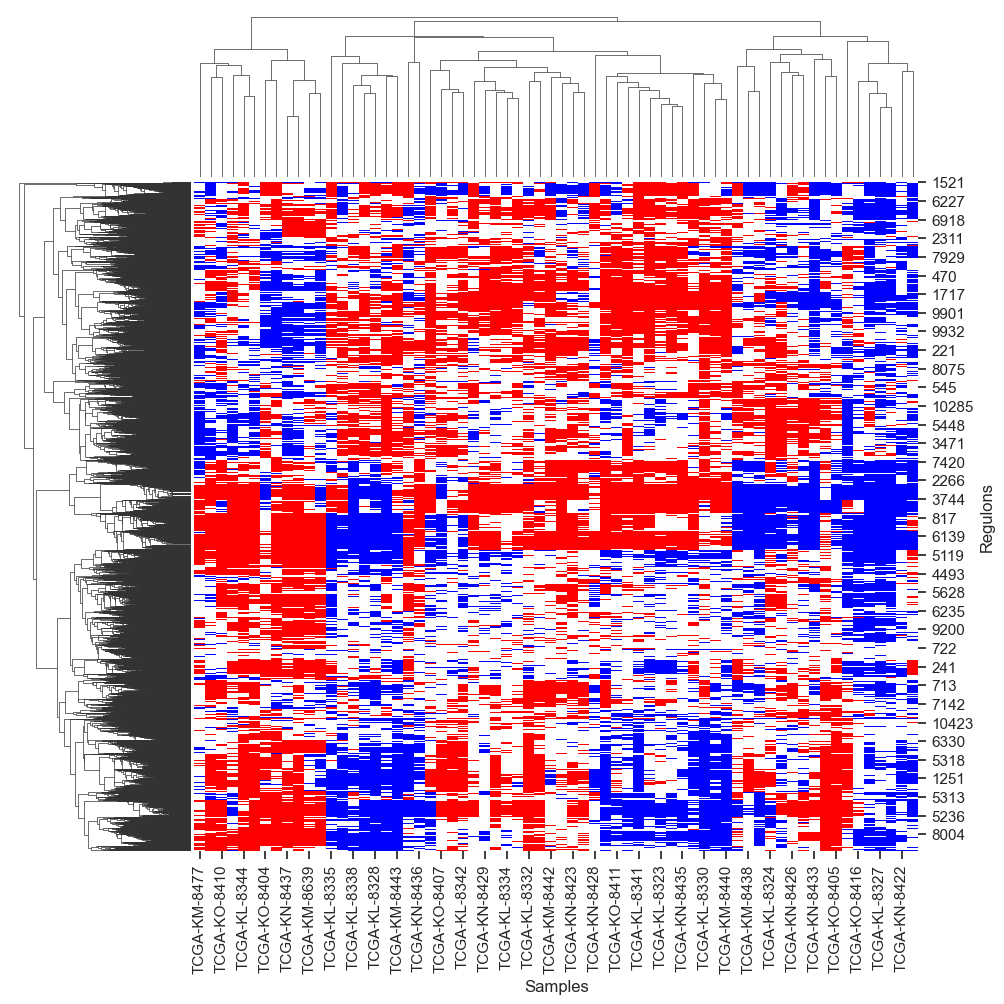

In [34]:
sns.set()
sns.set(font_scale=1.0)
sns.set_style("ticks", {"xtick.minor.size": 1, "ytick.minor.size": 0.1})
g = sns.clustermap(diff_mmrf, 
               cmap="bwr", figsize=(10,10))

#g.ax_heatmap.set_xticklabels([])
#g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xlabel('Samples')
g.ax_heatmap.set_ylabel('Regulons')

g.cax.set_visible(False)
g.fig.savefig(os.path.join(results_folder, 'miner_regulon_biclusters.png'), format='png')